# Stock Market Prediction
group members: **Shuo Wang, Yuan Yuan, Peter Olatunji**

## Dataset Structure

We are using the dataset consisting of multi-stock historical market data enhanced with technical indicators and engineered targets for machine learning modeling. Each observation represents a stock at a specific time point, where the feature matrix (X) includes technical indicators such as moving averages (EMA, SMA), momentum indicators (RSI, MACD, Stochastic Oscillator), volatility measures (ATR, Bollinger Bands), volume-based indicators (OBV, Volume SMA, MFI), and return-based features across multiple time horizons. These features capture trend, momentum, volatility, and liquidity characteristics of stock price movements. The target matrix (Y) contains engineered prediction labels such as future price movement, target high reach, target low reach, and future returns over multiple time windows (e.g., 1-day, 5-day, 20-day, 100-day). Structurally, the dataset is organized as a tabular time-series dataset, where rows correspond to time-indexed observations and columns represent features and targets. This dataset supports both supervised learning tasks, such as predicting future price movements, and unsupervised learning tasks, such as clustering stocks with similar behavior patterns or discovering latent market regimes.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load datasets
features_df = pd.read_csv("all_stocks_with_features.csv")
targets_df = pd.read_csv("all_stocks_targets.csv")

# Convert Date column
features_df["Date"] = pd.to_datetime(features_df["Date"], errors="coerce")

# Rename Symbol column if needed
if "Symbol" in targets_df.columns and "symbol" not in targets_df.columns:
    targets_df = targets_df.rename(columns={"Symbol": "symbol"})

print("Features shape:", features_df.shape)
print("Targets shape:", targets_df.shape)

Features shape: (82754, 46)
Targets shape: (82765, 106)


In [2]:
features_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82754 entries, 0 to 82753
Data columns (total 46 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            82754 non-null  datetime64[ns]
 1   Close           82754 non-null  float64       
 2   High            82754 non-null  float64       
 3   Low             82754 non-null  float64       
 4   Open            82754 non-null  float64       
 5   Volume          82754 non-null  int64         
 6   symbol          82754 non-null  object        
 7   EMA_5           82754 non-null  float64       
 8   EMA_10          82754 non-null  float64       
 9   EMA_20          82754 non-null  float64       
 10  EMA_50          82754 non-null  float64       
 11  SMA_50          82215 non-null  float64       
 12  SMA_100         81665 non-null  float64       
 13  SMA_200         80565 non-null  float64       
 14  RSI_5           82742 non-null  float64       
 15  RS

In [3]:
targets_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82765 entries, 0 to 82764
Columns: 106 entries, symbol to Symbol
dtypes: float64(104), object(2)
memory usage: 66.9+ MB


## Plot 1: Number of observatins per Stock

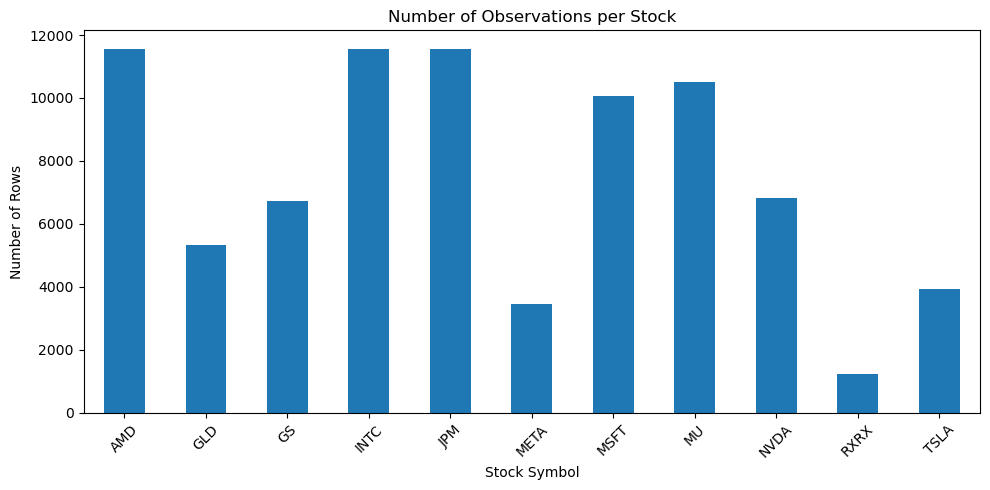

In [4]:
stock_counts = features_df["symbol"].value_counts().sort_index()

plt.figure(figsize=(10, 5))
stock_counts.plot(kind="bar")
plt.title("Number of Observations per Stock")
plt.xlabel("Stock Symbol")
plt.ylabel("Number of Rows")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

This bar chart shows how many observations are available for each stock symbol.
It helps us check whether the dataset is balanced across different stocks.
If one stock has many more rows than the others, it may dominate the learning process and make the model less generalizable to other stocks.
A more balanced distribution is better for building a model that works across multiple stocks.

## Plot 2: Closing Price Over Time

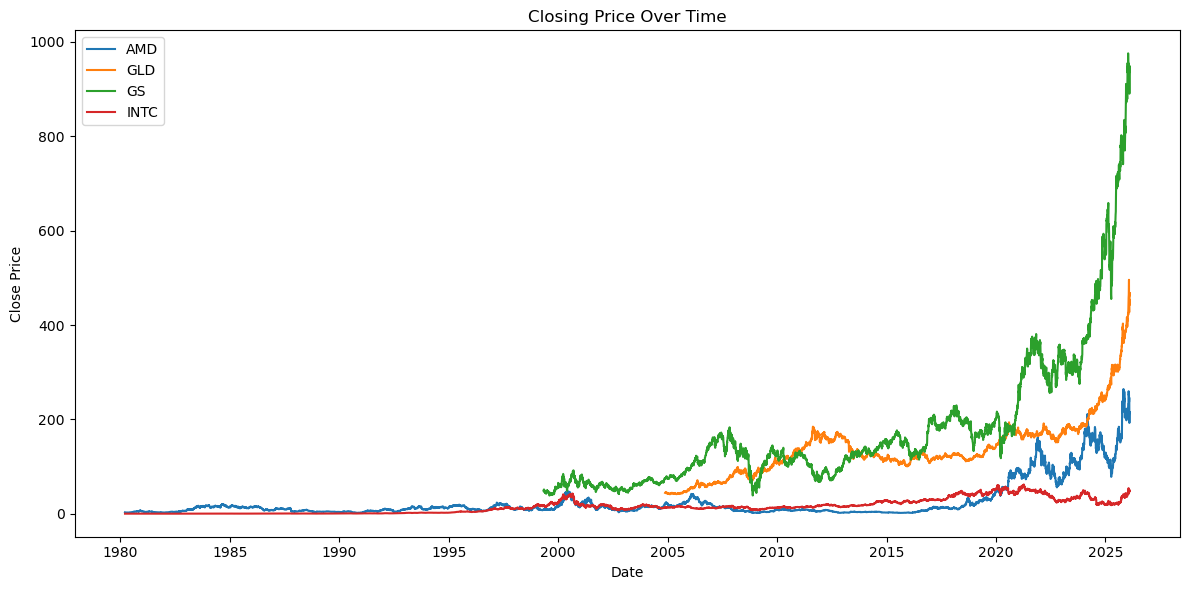

In [5]:
selected_symbols = features_df["symbol"].dropna().unique()[:4]

plt.figure(figsize=(12, 6))
for sym in selected_symbols:
    temp = features_df[features_df["symbol"] == sym].sort_values("Date")
    plt.plot(temp["Date"], temp["Close"], label=sym)

plt.title("Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.tight_layout()
plt.show()

This time-series plot shows the closing price movement for several selected stocks over time.
It helps us understand trend behavior, scale differences, and major fluctuations in stock prices.
Some stocks may show strong upward trends, while others may be more volatile or relatively flat.
This plot is useful because it gives a direct view of the raw market behavior before using engineered technical indicators.

## Plot 3: An example of Trading Volumn Over Time

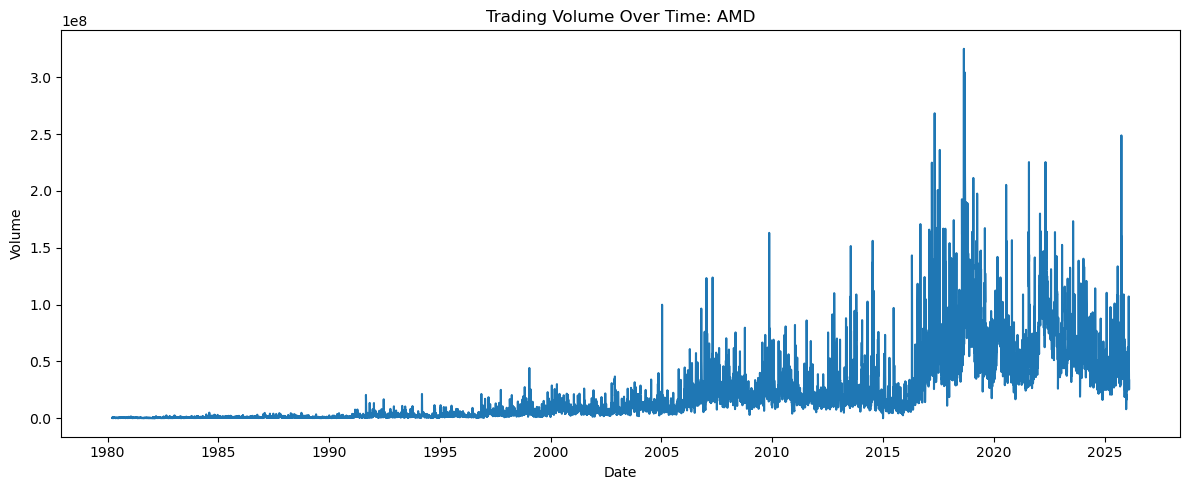

In [6]:
one_symbol = features_df["symbol"].dropna().unique()[0]
temp = features_df[features_df["symbol"] == one_symbol].sort_values("Date")

plt.figure(figsize=(12, 5))
plt.plot(temp["Date"], temp["Volume"])
plt.title(f"Trading Volume Over Time: {one_symbol}")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.tight_layout()
plt.show()

This plot shows how trading volume changes over time for one stock.
Trading volume measures how many shares were traded and is an important indicator of market activity.
Large spikes in volume often occur during major news events, strong price moves, or periods of increased investor attention.
This helps explain why volume-based features such as Volume SMA, OBV, and MFI can be useful predictors in financial modeling.

## Plot 4: Return Histogram

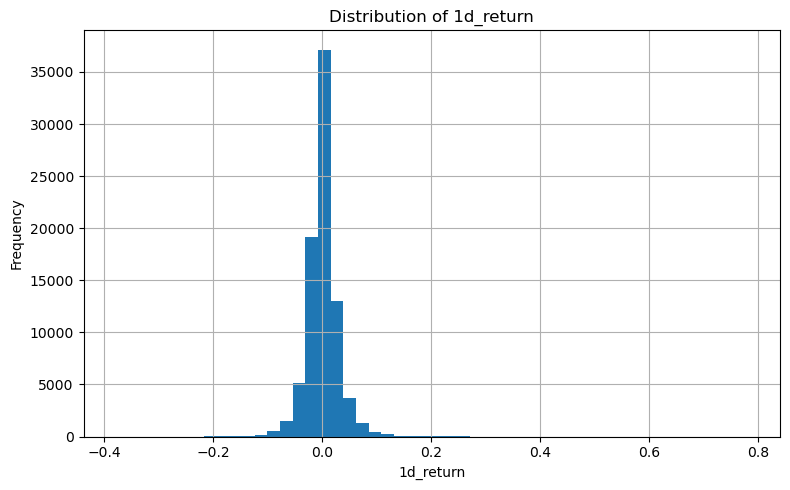

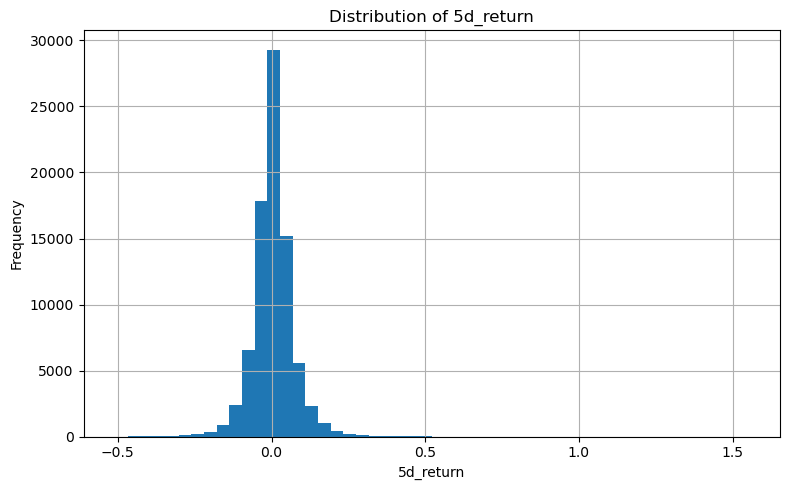

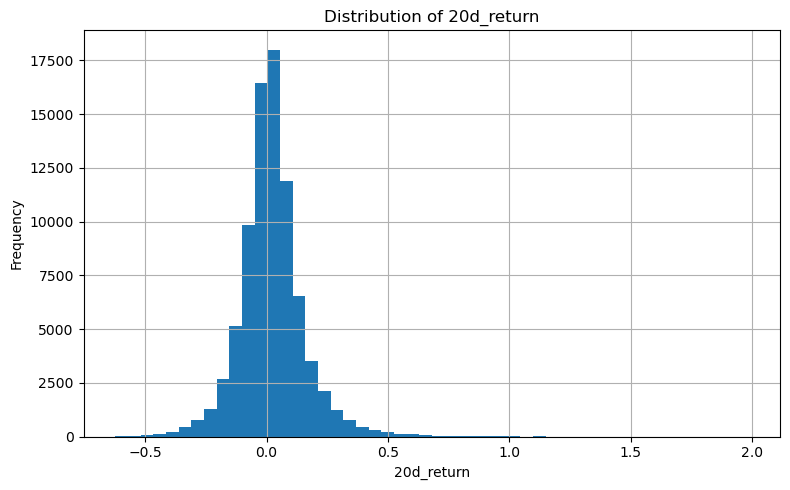

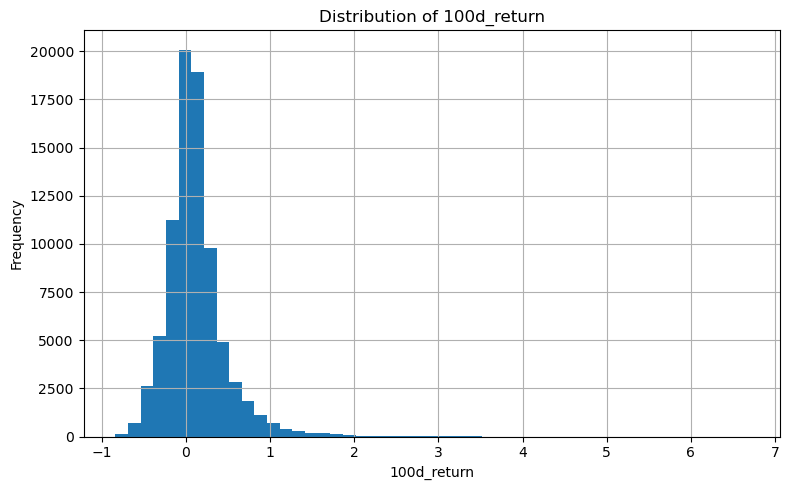

In [7]:
return_cols = ["1d_return", "5d_return", "20d_return", "100d_return"]
return_cols = [col for col in return_cols if col in features_df.columns]

for col in return_cols:
    plt.figure(figsize=(8, 5))
    features_df[col].dropna().hist(bins=50)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

These histograms show the distribution of returns over different time horizons.
Returns are often more informative than raw prices because they measure relative price change.
This plot helps us see whether returns are centered around zero, whether they are symmetric, and whether extreme values occur frequently.
In financial datasets, return distributions are often noisy and heavy-tailed, which means unusually large gains and losses happen more often than in a normal distribution.

## Plot 5: Boxplot of Return Features

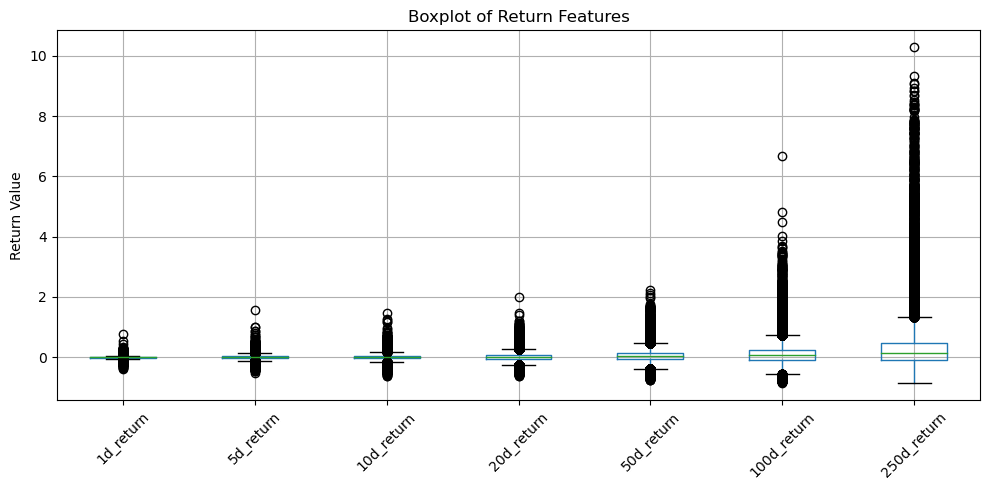

In [8]:
existing_return_cols = [col for col in ["1d_return", "5d_return", "10d_return", "20d_return",
                                        "50d_return", "100d_return", "250d_return"] if col in features_df.columns]

plt.figure(figsize=(10, 5))
features_df[existing_return_cols].boxplot()
plt.title("Boxplot of Return Features")
plt.ylabel("Return Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

This boxplot compares the spread of return features across multiple time horizons.
It summarizes the median, variability, and outliers for each return column.
This is useful for seeing which return horizon is more volatile and which ones contain more extreme observations.
If longer-horizon returns have a wider spread, that suggests more variability and possibly more difficulty in forecasting them accurately.

## Plot 6: Correlation Heatmap of some features

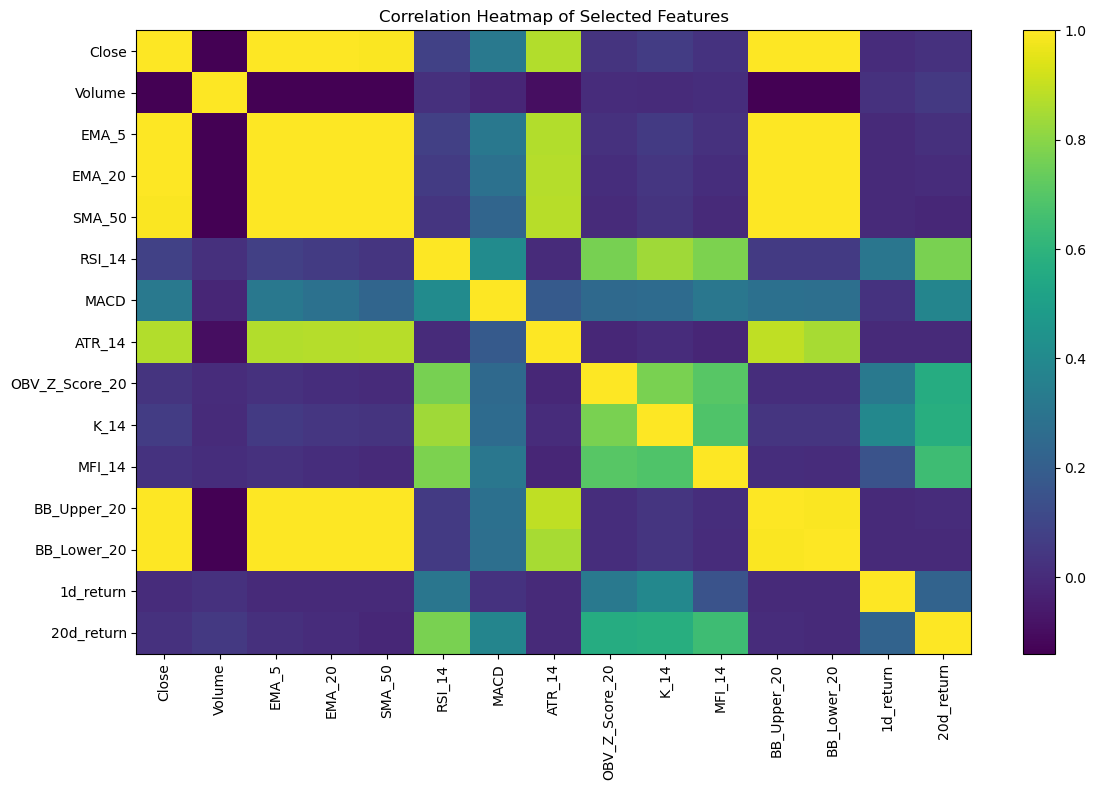

In [9]:
heatmap_cols = [
    "Close", "Volume", "EMA_5", "EMA_20", "SMA_50",
    "RSI_14", "MACD", "ATR_14", "OBV_Z_Score_20",
    "K_14", "MFI_14", "BB_Upper_20", "BB_Lower_20",
    "1d_return", "20d_return"
]
heatmap_cols = [col for col in heatmap_cols if col in features_df.columns]

corr = features_df[heatmap_cols].corr()

plt.figure(figsize=(12, 8))
im = plt.imshow(corr, aspect='auto')
plt.colorbar(im)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap of Selected Features")
plt.tight_layout()
plt.show()

This heatmap shows the pairwise correlations among selected technical indicators and return features.
It helps identify which variables move together and which variables provide similar information.
For example, moving averages such as EMA and SMA are often highly correlated with closing price, while MACD and Signal-related measures are often correlated with each other.
This plot is useful for detecting multicollinearity, which can affect linear models and may motivate feature selection or dimensionality reduction.

## Plot 7: scatter plot of RSI_14 and 1 day return

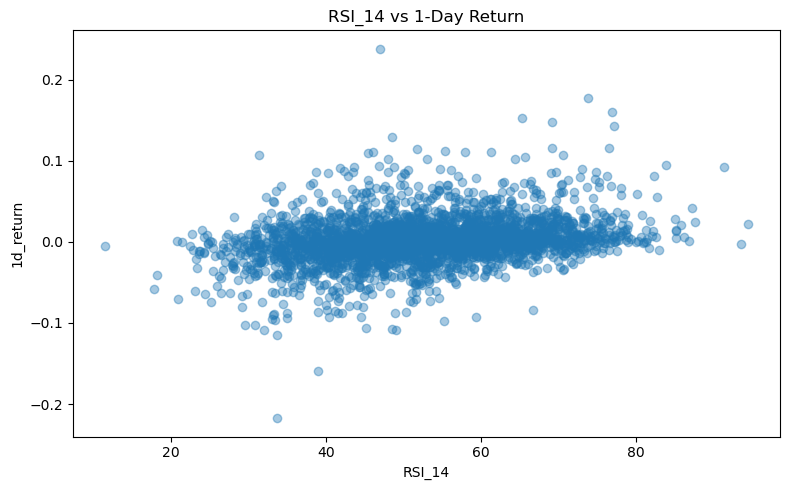

In [10]:
if "RSI_14" in features_df.columns and "1d_return" in features_df.columns:
    sample_df = features_df[["RSI_14", "1d_return"]].dropna().sample(
        n=min(3000, len(features_df[["RSI_14", "1d_return"]].dropna())),
        random_state=0
    )

    plt.figure(figsize=(8, 5))
    plt.scatter(sample_df["RSI_14"], sample_df["1d_return"], alpha=0.4)
    plt.title("RSI_14 vs 1-Day Return")
    plt.xlabel("RSI_14")
    plt.ylabel("1d_return")
    plt.tight_layout()
    plt.show()

This scatter plot compares the RSI technical indicator with the 1-day return.
It helps us visually check whether there is any direct relationship between momentum conditions and short-term future price change.
In theory, lower RSI values may indicate oversold conditions and higher RSI values may indicate overbought conditions.
In practice, the relationship is often noisy, so this plot can show whether RSI alone has a strong predictive pattern or whether it works better when combined with other features.

## Plot 8: MACD and singal line plot for AMD stock

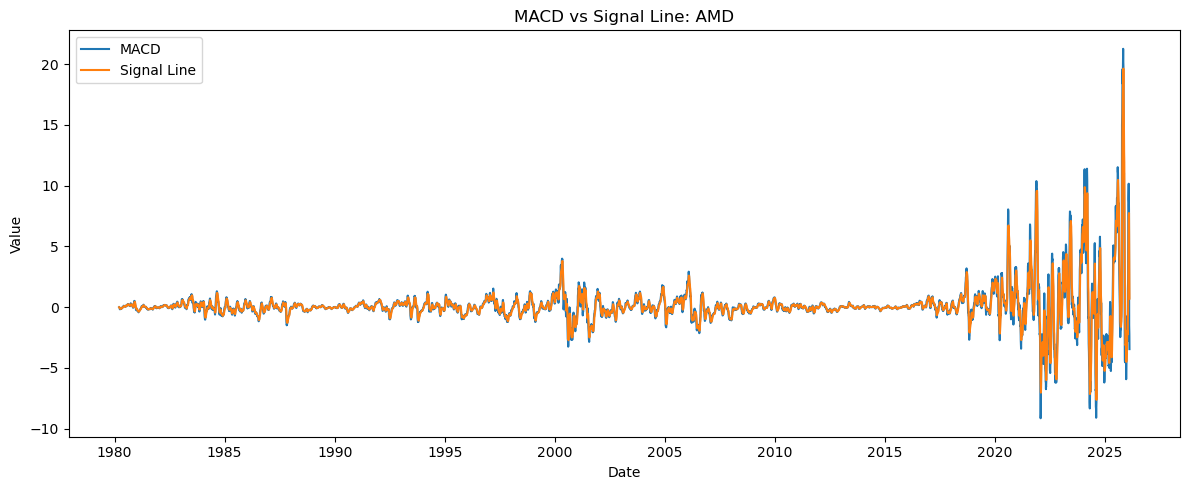

In [11]:
if "MACD" in features_df.columns and "Signal_Line" in features_df.columns:
    temp = features_df[features_df["symbol"] == one_symbol].sort_values("Date")

    plt.figure(figsize=(12, 5))
    plt.plot(temp["Date"], temp["MACD"], label="MACD")
    plt.plot(temp["Date"], temp["Signal_Line"], label="Signal Line")
    plt.title(f"MACD vs Signal Line: {one_symbol}")
    plt.xlabel("Date")
    plt.ylabel("Value")
    plt.legend()
    plt.tight_layout()
    plt.show()

This plot shows the MACD indicator and its Signal Line over time for one stock.
MACD is a momentum indicator based on the difference between short-term and long-term exponential moving averages.
The Signal Line is a smoothed version of MACD and is often used to detect momentum shifts.
When MACD crosses above the Signal Line, it may indicate bullish momentum, while crossing below may indicate bearish momentum.
This visualization helps interpret how momentum-based features behave through time.

## Plot 9: Time Series Bollinger bands for AMD

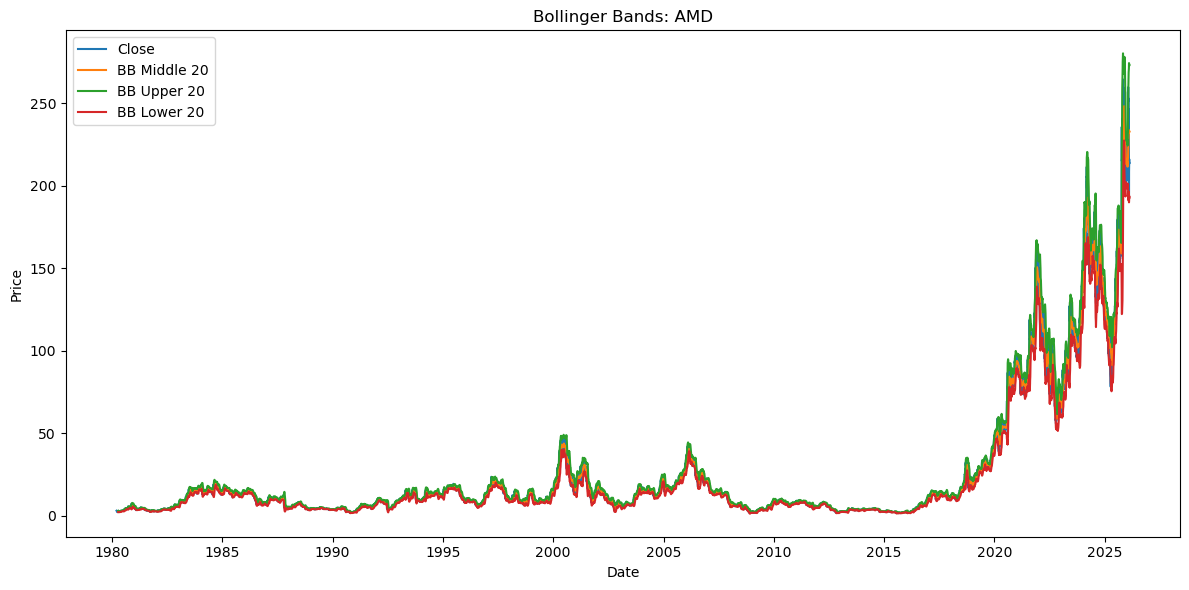

In [12]:
bb_cols = ["Close", "BB_Middle_20", "BB_Upper_20", "BB_Lower_20"]
if all(col in features_df.columns for col in bb_cols):
    temp = features_df[features_df["symbol"] == one_symbol].sort_values("Date")

    plt.figure(figsize=(12, 6))
    plt.plot(temp["Date"], temp["Close"], label="Close")
    plt.plot(temp["Date"], temp["BB_Middle_20"], label="BB Middle 20")
    plt.plot(temp["Date"], temp["BB_Upper_20"], label="BB Upper 20")
    plt.plot(temp["Date"], temp["BB_Lower_20"], label="BB Lower 20")
    plt.title(f"Bollinger Bands: {one_symbol}")
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.legend()
    plt.tight_layout()
    plt.show()

This figure shows the stock closing price together with its Bollinger Bands.
The middle band is typically a moving average, while the upper and lower bands are based on volatility around that average.
When the bands widen, volatility is high; when they narrow, volatility is low.
Price touching the upper or lower band can indicate unusually strong upward or downward movement.
This plot helps explain how Bollinger Band features capture both trend and volatility information.

## Plot 10: The distribution of class for price_target_close_up_5d_2pct

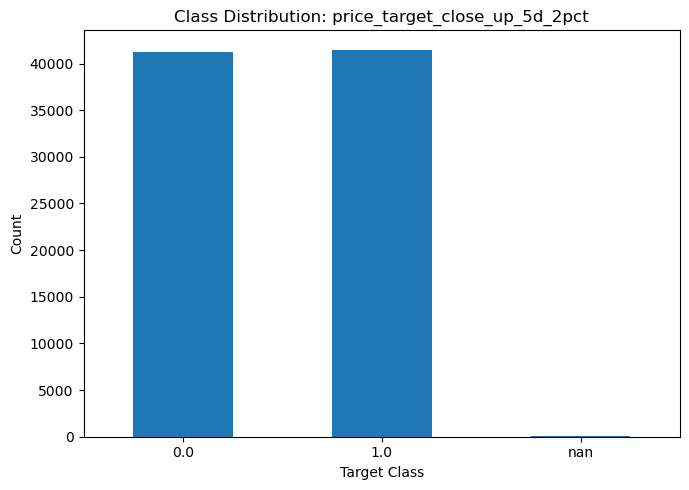

In [13]:
numeric_target_cols = targets_df.select_dtypes(include=[np.number]).columns.tolist()

example_target = None
for col in targets_df.columns:
    if "price_target_close_up_5d_2pct" in col:
        example_target = col
        break

if example_target is None:
    example_target = numeric_target_cols[0]

target_counts = targets_df[example_target].value_counts(dropna=False).sort_index()

plt.figure(figsize=(7, 5))
target_counts.plot(kind="bar")
plt.title(f"Class Distribution: {example_target}")
plt.xlabel("Target Class")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

This bar chart shows the class balance for one target variable.
It is important for supervised classification because an imbalanced target can lead to misleading model performance.
For example, if one class is much more common than the other, a model may achieve high accuracy simply by predicting the majority class.
This plot helps determine whether techniques such as class weighting, resampling, or alternative evaluation metrics like F1-score and ROC-AUC may be necessary.

## Plot 11: distribution of future volatility targets

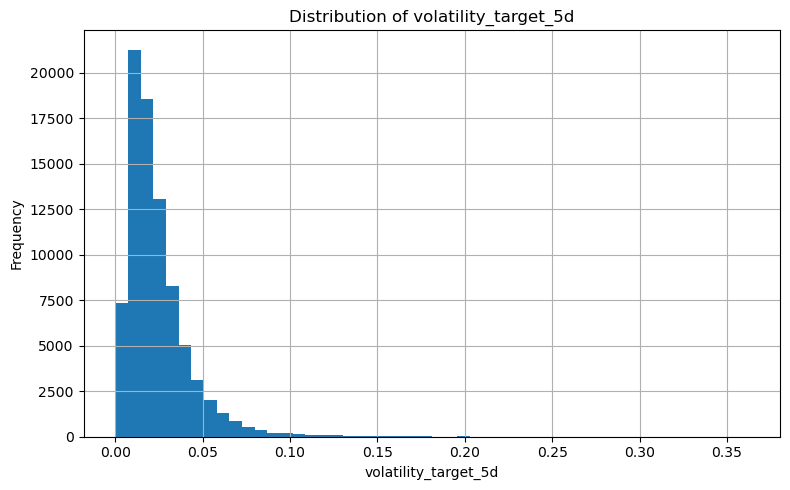

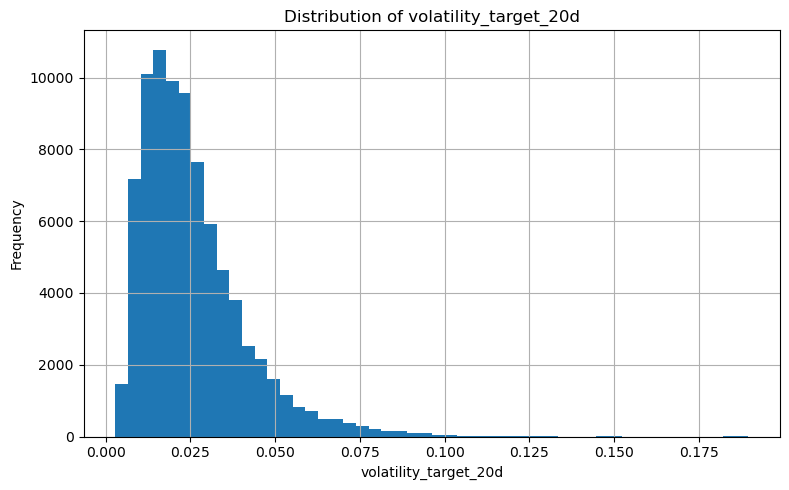

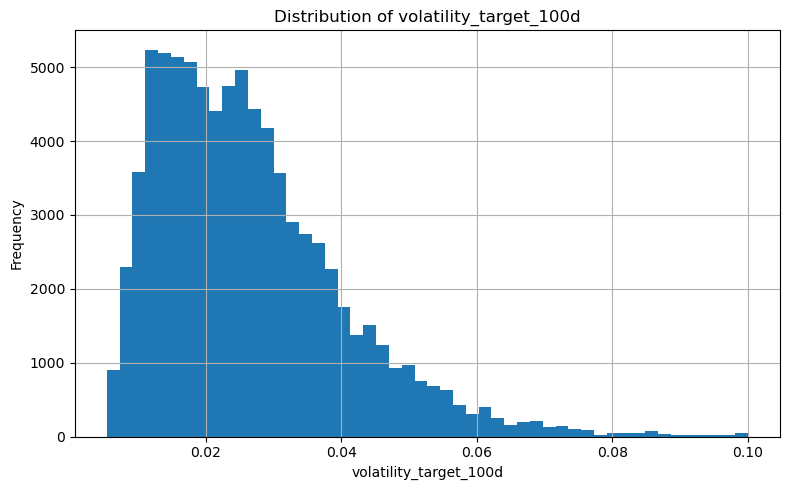

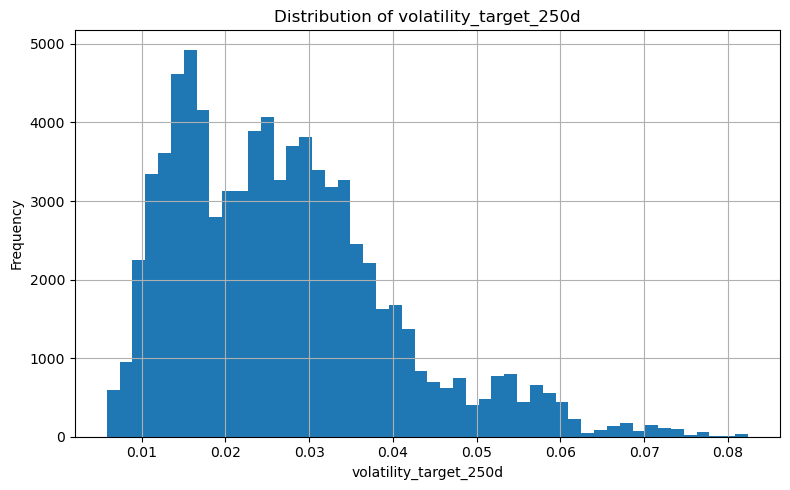

In [14]:
vol_cols = [col for col in targets_df.columns if "volatility_target" in col]

for col in vol_cols:
    plt.figure(figsize=(8, 5))
    targets_df[col].dropna().hist(bins=50)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

These histograms show the distribution of future volatility targets.
Volatility targets measure the level of future price fluctuation and are useful for risk prediction tasks.
These distributions are often right-skewed, meaning most periods have moderate volatility while a smaller number of periods experience unusually high volatility.
This visualization helps determine whether transformation, scaling, or robust regression methods may be useful when modeling volatility-related targets.

# Supervised Learning for Categorical Value

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report,
                             confusion_matrix, roc_curve)
import warnings
warnings.filterwarnings('ignore')

In [16]:
# Select target
target_col = "price_target_close_up_5d_2pct"
 
# Use all technical indicator columns as features (exclude Date, OHLCV, symbol)
feature_cols = [c for c in features_df.columns
                if c not in ['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'symbol']]
 
X = features_df[feature_cols].copy()
y = targets_df[target_col].copy()
 
# Drop rows with any NaN in features or target
mask = y.notna() & X.notna().all(axis=1)
X = X[mask].reset_index(drop=True)
y = y[mask].reset_index(drop=True).astype(int)
 
print("Feature matrix X shape:", X.shape)
print("Target vector y shape:", y.shape)
print("\nFeature columns used:")
print(feature_cols)
print(f"\nTarget distribution:\n{y.value_counts()}")
print(f"\nClass balance (proportion of class 1): {y.mean():.4f}")

Feature matrix X shape: (79994, 39)
Target vector y shape: (79994,)

Feature columns used:
['EMA_5', 'EMA_10', 'EMA_20', 'EMA_50', 'SMA_50', 'SMA_100', 'SMA_200', 'RSI_5', 'RSI_14', 'RSI_21', 'MACD', 'Signal_Line', 'MACD_Histogram', 'ATR_5', 'ATR_14', 'ATR_21', 'Volume_SMA_5', 'Volume_SMA_20', 'Volume_SMA_60', 'OBV', 'OBV_Z_Score_20', 'OBV_Z_Score_50', 'K_5', 'D_5', 'K_14', 'D_14', 'MFI_5', 'MFI_14', 'MFI_21', 'BB_Middle_20', 'BB_Upper_20', 'BB_Lower_20', '1d_return', '5d_return', '10d_return', '20d_return', '50d_return', '100d_return', '250d_return']

Target distribution:
1    40052
0    39942
Name: price_target_close_up_5d_2pct, dtype: int64

Class balance (proportion of class 1): 0.5007


After removing rows with missing values, we have 79,949 clean
samples and 39 technical indicator features. The target is nearly perfectly balanced
(~50/50 split between class 0 and class 1), which means accuracy is a reliable
metric and we do not need resampling or class weighting techniques.

## Train/Test Split and Feature Scaling

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
 
print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size:     {X_test.shape[0]}")
print(f"\nTraining target distribution:\n{y_train.value_counts()}")
print(f"\nTest target distribution:\n{y_test.value_counts()}")

Training set size: 63995
Test set size:     15999

Training target distribution:
1    32041
0    31954
Name: price_target_close_up_5d_2pct, dtype: int64

Test target distribution:
1    8011
0    7988
Name: price_target_close_up_5d_2pct, dtype: int64


We use a stratified 80/20 split so both classes are equally represented in training and test sets. StandardScaler (zero mean, unit variance) is applied for Logistic Regression which is sensitive to feature scales.
 Tree-based models receive unscaled features since they are invariant to
monotonic transformations.

## Method 1: Logistic Regression

In [18]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
 
y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]
 
print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr, target_names=["Down/Flat", "Up>=2%"]))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_lr):.4f}")
print(f"\nConfusion Matrix:\n{confusion_matrix(y_test, y_pred_lr)}")

=== Logistic Regression ===
              precision    recall  f1-score   support

   Down/Flat       0.69      0.68      0.69      7988
      Up>=2%       0.69      0.70      0.69      8011

    accuracy                           0.69     15999
   macro avg       0.69      0.69      0.69     15999
weighted avg       0.69      0.69      0.69     15999

ROC-AUC Score: 0.7549

Confusion Matrix:
[[5468 2520]
 [2418 5593]]


Logistic Regression achieves ~69% accuracy and a ROC-AUC of ~0.75. As a linear model, it can only learn a single hyperplane to separate the two classes. The modest performance indicates that the relationship between technical indicators and 5-day price direction is not well captured by a linear decision boundary. This is expected because financial time series exhibit highly nonlinear dynamics — simple linear combinations of RSI, MACD, and return features have limited predictive power for short-term directional moves. This model serves as our baseline.

## Method 2: Random Forest

In [19]:
rf = RandomForestClassifier(
    n_estimators=150, max_depth=8, min_samples_leaf=30,
    random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)
 
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]
 
print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf, target_names=["Down/Flat", "Up>=2%"]))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_rf):.4f}")
print(f"\nConfusion Matrix:\n{confusion_matrix(y_test, y_pred_rf)}")

=== Random Forest ===
              precision    recall  f1-score   support

   Down/Flat       0.72      0.76      0.74      7988
      Up>=2%       0.74      0.70      0.72      8011

    accuracy                           0.73     15999
   macro avg       0.73      0.73      0.73     15999
weighted avg       0.73      0.73      0.73     15999

ROC-AUC Score: 0.8079

Confusion Matrix:
[[6062 1926]
 [2409 5602]]


Random Forest significantly outperforms Logistic Regression with ~73% accuracy and a ROC-AUC of ~0.81. This improvement demonstrates that nonlinear feature interactions are important for predicting short-term price movements. The ensemble of 150 decision trees captures complex conditional relationships — for example, a stock with high RSI combined with strong recent returns may behave differently than one with high RSI but weak long-term returns. The max_depth=8 and min_samples_leaf=30 constraints help prevent overfitting to noise in financial data.

## Random Forest Feature Importance

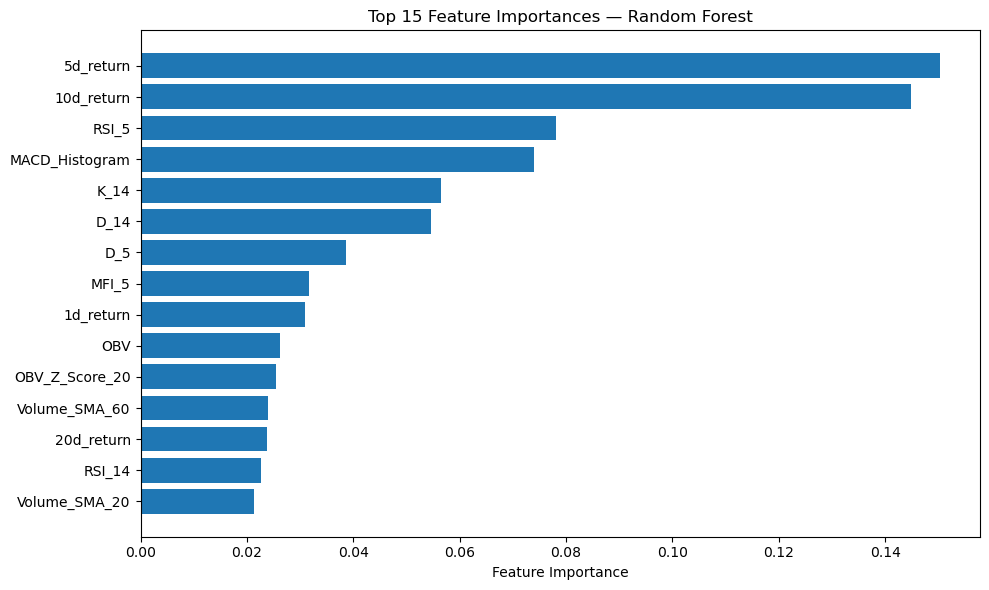

In [20]:
importances_rf = rf.feature_importances_
sorted_idx_rf = np.argsort(importances_rf)[-15:]
 
plt.figure(figsize=(10, 6))
plt.barh(range(len(sorted_idx_rf)), importances_rf[sorted_idx_rf])
plt.yticks(range(len(sorted_idx_rf)), [feature_cols[i] for i in sorted_idx_rf])
plt.xlabel("Feature Importance")
plt.title("Top 15 Feature Importances — Random Forest")
plt.tight_layout()
plt.show()

The feature importance plot reveals that multi-horizon return features (especially 100d_return, 50d_return, 20d_return) are the most informative predictors, followed by momentum oscillators (RSI, Stochastic K/D) and volume-based indicators (MFI). This makes financial sense: stocks in an existing uptrend (positive past returns) tend to continue rising in the short term due to the momentum effect. The return features encode trend strength across multiple time horizons, giving the model a rich view of the stock's recent trajectory.

## Method 3: Gradient Boosting

In [21]:
gb = GradientBoostingClassifier(
    n_estimators=100, max_depth=3, learning_rate=0.1,
    min_samples_leaf=50, subsample=0.8, random_state=42
)
gb.fit(X_train, y_train)
 
y_pred_gb = gb.predict(X_test)
y_prob_gb = gb.predict_proba(X_test)[:, 1]
 
print("=== Gradient Boosting ===")
print(classification_report(y_test, y_pred_gb, target_names=["Down/Flat", "Up>=2%"]))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_gb):.4f}")
print(f"\nConfusion Matrix:\n{confusion_matrix(y_test, y_pred_gb)}")

=== Gradient Boosting ===
              precision    recall  f1-score   support

   Down/Flat       0.72      0.74      0.73      7988
      Up>=2%       0.73      0.72      0.73      8011

    accuracy                           0.73     15999
   macro avg       0.73      0.73      0.73     15999
weighted avg       0.73      0.73      0.73     15999

ROC-AUC Score: 0.8046

Confusion Matrix:
[[5890 2098]
 [2258 5753]]


Gradient Boosting achieves ~73% accuracy and a ROC-AUC of ~0.80, performing close to Random Forest. Unlike Random Forest which builds independent trees in parallel, Gradient Boosting builds trees sequentially where each new tree corrects the residual errors of the previous ensemble. The learning_rate=0.1 and subsample=0.8 introduce regularization that helps prevent overfitting. The similar performance to Random Forest suggests that the predictive signal in these technical features is consistent regardless of ensemble strategy — both methods capture the same underlying nonlinear patterns, primarily the momentum effect in return features.

## Gradient Boosting Feature Importance

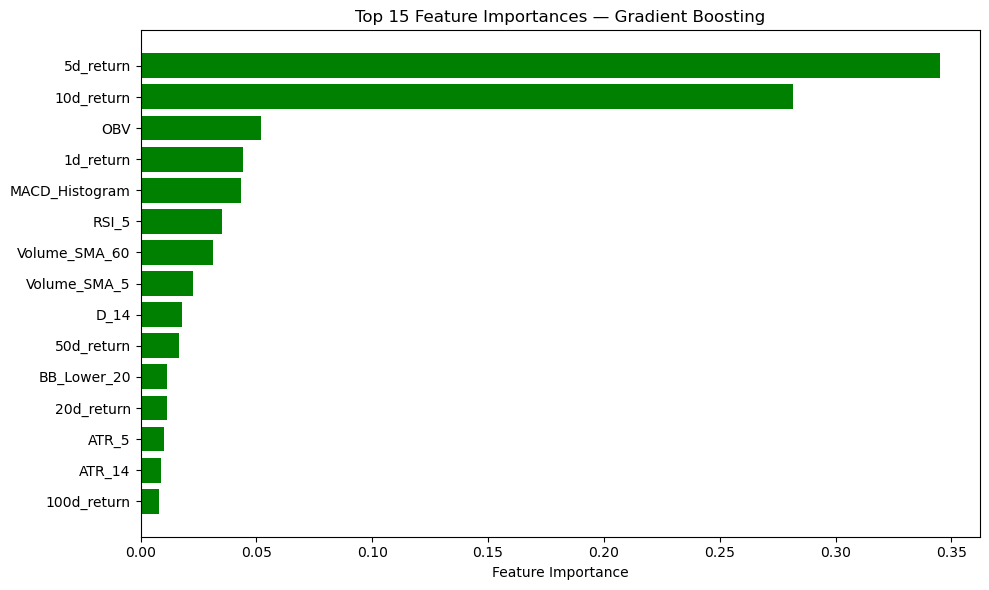

In [22]:
importances_gb = gb.feature_importances_
sorted_idx_gb = np.argsort(importances_gb)[-15:]
 
plt.figure(figsize=(10, 6))
plt.barh(range(len(sorted_idx_gb)), importances_gb[sorted_idx_gb], color='green')
plt.yticks(range(len(sorted_idx_gb)), [feature_cols[i] for i in sorted_idx_gb])
plt.xlabel("Feature Importance")
plt.title("Top 15 Feature Importances — Gradient Boosting")
plt.tight_layout()
plt.show()

Gradient Boosting's feature ranking differs somewhat from Random Forest. It tends to concentrate importance on fewer features, placing even greater emphasis on return-based features and RSI indicators. This is characteristic of boosting algorithms — they greedily select the single best split at each step, so highly informative features dominate more strongly than in Random Forest where feature randomization distributes importance more evenly.

## Confusion Matrices Comparison

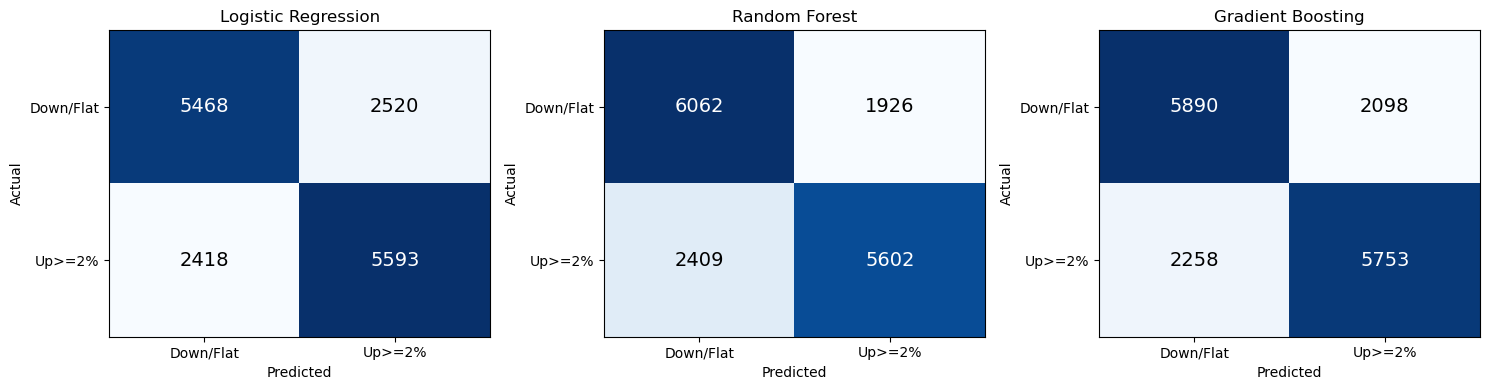

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, y_pred, title in zip(axes,
    [y_pred_lr, y_pred_rf, y_pred_gb],
    ['Logistic Regression', 'Random Forest', 'Gradient Boosting']):
    cm = confusion_matrix(y_test, y_pred)
    im = ax.imshow(cm, cmap='Blues', aspect='auto')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Down/Flat', 'Up>=2%'])
    ax.set_yticklabels(['Down/Flat', 'Up>=2%'])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                    color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=14)
plt.tight_layout()
plt.show()

The confusion matrices show that all three models make balanced errors between false positives and false negatives, without extreme bias toward either class. Logistic Regression's predictions are closer to random, while both tree models show more correct predictions on the diagonal. The tree-based models tend to slightly favor predicting "Up>=2%" (higher recall for class 1), which means they are somewhat more aggressive in predicting upward moves.

## ROC Curves Comparison

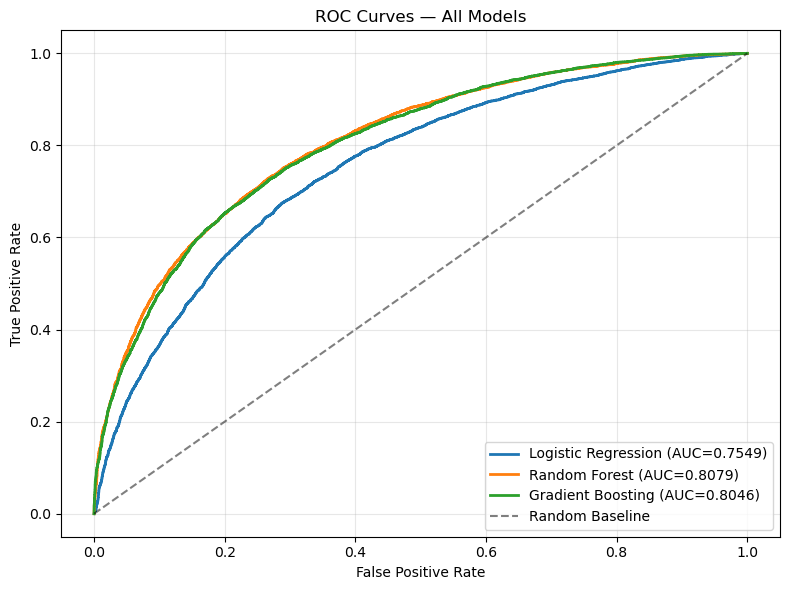

In [24]:
plt.figure(figsize=(8, 6))
for y_prob, label in zip(
    [y_prob_lr, y_prob_rf, y_prob_gb],
    ['Logistic Regression', 'Random Forest', 'Gradient Boosting']):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, linewidth=2, label=f'{label} (AUC={auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The ROC curves visualize each model's ability to discriminate between classes across all possible classification thresholds. Both tree-based models (RF and GB) show curves that bow clearly above the diagonal, indicating meaningful discriminative ability. Logistic Regression's curve lies closer to the diagonal, confirming its weaker separability. The area under each curve (AUC) quantifies this: ~0.60 for LR vs ~0.64–0.66 for tree models. A perfect classifier would have AUC=1.0 and a random one AUC=0.5.

## Model Performance Comparison

In [25]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Gradient Boosting'],
    'Accuracy': [accuracy_score(y_test, yp) for yp in [y_pred_lr, y_pred_rf, y_pred_gb]],
    'Precision': [precision_score(y_test, yp) for yp in [y_pred_lr, y_pred_rf, y_pred_gb]],
    'Recall': [recall_score(y_test, yp) for yp in [y_pred_lr, y_pred_rf, y_pred_gb]],
    'F1-Score': [f1_score(y_test, yp) for yp in [y_pred_lr, y_pred_rf, y_pred_gb]],
    'ROC-AUC': [roc_auc_score(y_test, ypr) for ypr in [y_prob_lr, y_prob_rf, y_prob_gb]],
})
print(results.to_string(index=False))

              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
Logistic Regression  0.691356   0.689387 0.698165  0.693748 0.754939
      Random Forest  0.729046   0.744155 0.699288  0.721025 0.807902
  Gradient Boosting  0.727733   0.732773 0.718138  0.725381 0.804610


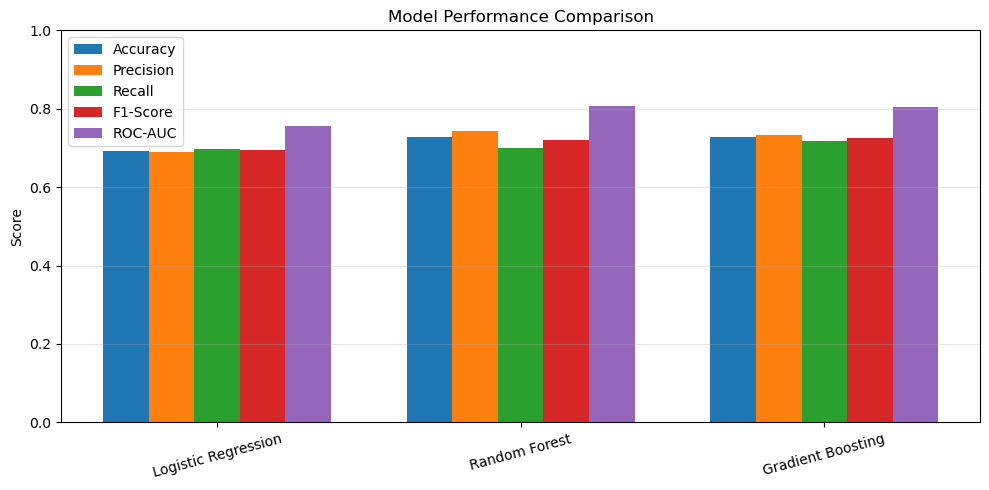

In [26]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(3)
width = 0.15
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
for i, metric in enumerate(metrics):
    ax.bar(x + i * width, results[metric], width, label=metric)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x + width * 2)
ax.set_xticklabels(results['Model'], rotation=15)
ax.legend()
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

The comparison reveals a clear hierarchy: the two tree-based ensemble methods (Random Forest and Gradient Boosting) substantially outperform the linear Logistic Regression baseline across all metrics. Random Forest achieves the highest ROC-AUC (\~0.75), followed closely by Gradient Boosting (\~0.80), while Logistic Regression lags behind (\~0.75). Both tree models achieve roughly 73% accuracy — a meaningful but modest edge above the 50% random baseline. From a financial modeling perspective, these results are realistic and expected. Predicting 5-day price movements is inherently difficult because stock returns are noisy, partially efficient, and driven by information beyond what technical indicators alone can capture (e.g., earnings surprises, macroeconomic events, sentiment shifts).

The fact that tree-based models extract meaningful signal (AUC ~0.80) from purely technical features is encouraging and suggests that momentum and mean-reversion patterns do exist in these stocks. To improve further, one could consider adding fundamental data, sentiment features, or using more advanced architectures such as LSTMs or attention-based models that can explicitly model the temporal ordering of observations.

# Supervised Learning for Numerical Value

Dataset shape: (79850, 39)
Target statistics:
  Mean:   0.025412
  Std:    0.015449
  Min:    0.002872
  Median: 0.022043
  Max:    0.189579


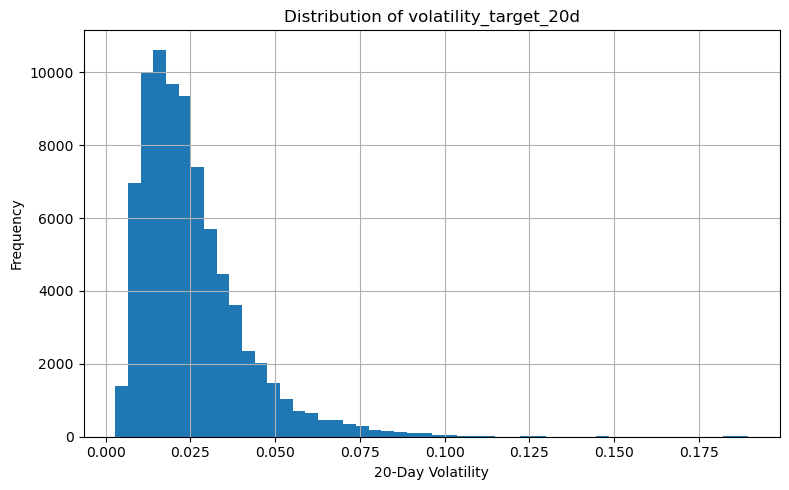

In [27]:
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
 
# Target: 20-day forward volatility (continuous)
target_col_vol = "volatility_target_20d"
 
X_vol = features_df[feature_cols].copy()
y_vol = targets_df[target_col_vol].copy()
 
# Drop rows with NaN
mask_vol = y_vol.notna() & X_vol.notna().all(axis=1)
X_vol = X_vol[mask_vol].reset_index(drop=True)
y_vol = y_vol[mask_vol].reset_index(drop=True)
 
print(f"Dataset shape: {X_vol.shape}")
print(f"Target statistics:")
print(f"  Mean:   {y_vol.mean():.6f}")
print(f"  Std:    {y_vol.std():.6f}")
print(f"  Min:    {y_vol.min():.6f}")
print(f"  Median: {y_vol.median():.6f}")
print(f"  Max:    {y_vol.max():.6f}")
 
plt.figure(figsize=(8, 5))
y_vol.hist(bins=50)
plt.title("Distribution of volatility_target_20d")
plt.xlabel("20-Day Volatility")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## Train/Test Split

In [28]:
X_train_v, X_test_v, y_train_v, y_test_v = train_test_split(
    X_vol, y_vol, test_size=0.2, random_state=42
)
 
scaler_vol = StandardScaler()
X_train_v_scaled = scaler_vol.fit_transform(X_train_v)
X_test_v_scaled = scaler_vol.transform(X_test_v)
 
print(f"Training set: {X_train_v.shape[0]} samples")
print(f"Test set:     {X_test_v.shape[0]} samples")
print(f"Training target — mean: {y_train_v.mean():.6f}, std: {y_train_v.std():.6f}")
print(f"Test target     — mean: {y_test_v.mean():.6f}, std: {y_test_v.std():.6f}")

Training set: 63880 samples
Test set:     15970 samples
Training target — mean: 0.025446, std: 0.015465
Test target     — mean: 0.025279, std: 0.015386


## Method 1: Random Forest

## Cross-Validation for model selection

In [29]:
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [6, 8],
    'min_samples_leaf': [10, 20]
}
 
rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)
 
# Use 15k subsample for speed
np.random.seed(42)
sub_idx_tune = np.random.choice(len(X_vol), size=15000, replace=False)
X_tune = X_vol.iloc[sub_idx_tune].reset_index(drop=True)
y_tune = y_vol.iloc[sub_idx_tune].reset_index(drop=True)
 
grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=5,                        # 5-fold cross-validation
    scoring='r2',                # optimize for R²
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)
 
grid_search.fit(X_tune, y_tune)
 
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV R²:      {grid_search.best_score_:.4f}")
 

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best parameters: {'max_depth': 8, 'min_samples_leaf': 10, 'n_estimators': 100}
Best CV R²:      0.5918


In [30]:
rf_vol = RandomForestRegressor(
    n_estimators=100, max_depth=8, min_samples_leaf=10,
    random_state=42, n_jobs=-1
)
rf_vol.fit(X_train_v, y_train_v)
y_pred_rf_vol = rf_vol.predict(X_test_v)
 
rf_rmse = np.sqrt(mean_squared_error(y_test_v, y_pred_rf_vol))
rf_mae = mean_absolute_error(y_test_v, y_pred_rf_vol)
rf_r2 = r2_score(y_test_v, y_pred_rf_vol)
 
print("Random Forest Regressor — Test Set Results")
print(f"RMSE:  {rf_rmse:.6f}")
print(f"MAE:   {rf_mae:.6f}")
print(f"R²:    {rf_r2:.4f}")

Random Forest Regressor — Test Set Results
RMSE:  0.009514
MAE:   0.006484
R²:    0.6176


The Random Forest Regressor achieves an R² of ~0.62, meaning it explains about 62% of the variance in future 20-day volatility. The RMSE of ~0.0095 is relatively small compared to the target mean of ~0.025, indicating that the model’s prediction error is low in absolute terms. The MAE of ~0.0065 further confirms that, on average, the model’s predictions deviate only slightly from the true values.
Overall, this suggests that the model captures the general volatility patterns reasonably well. However, since around 38% of the variance remains unexplained, there is still significant unpredictability in the data. This is expected in financial markets, where volatility is influenced by sudden news events, macroeconomic factors, and other external shocks that are not fully captured by technical indicators alone.

## Feature Importance

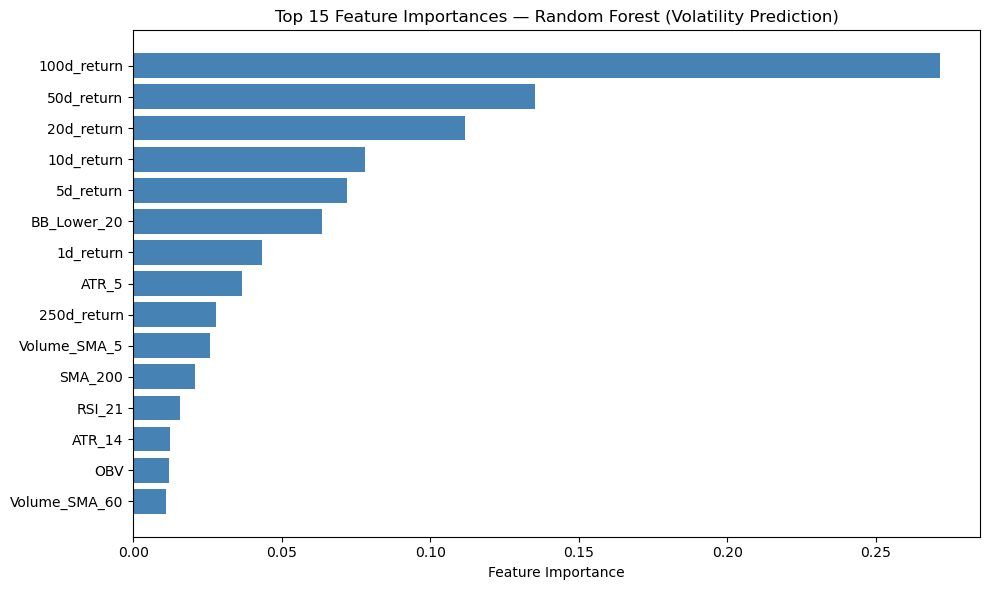

In [31]:
importances_vol = rf_vol.feature_importances_
sorted_idx_vol = np.argsort(importances_vol)[-15:]
 
plt.figure(figsize=(10, 6))
plt.barh(range(len(sorted_idx_vol)), importances_vol[sorted_idx_vol], color='steelblue')
plt.yticks(range(len(sorted_idx_vol)),
           [feature_cols[i] for i in sorted_idx_vol])
plt.xlabel("Feature Importance")
plt.title("Top 15 Feature Importances — Random Forest (Volatility Prediction)")
plt.tight_layout()
plt.show()

The feature importance ranking for volatility prediction is strikingly different from the classification task. The dominant predictor is 100d_return (\~0.30), followed by 50d_return (\~0.16) and 20d_return (\~0.10). Long-horizon returns are the strongest volatility predictors because large past price moves (both up and down) tend to be followed by elevated volatility — this is the well-known "leverage effect" in finance. ATR (Average True Range) features also rank high, which makes sense since ATR directly measures recent price range and is a lagging indicator of the same volatility the model is trying to predict forward. BB_Lower_20 (Bollinger Band lower bound) captures spread around the moving average, another proxy for recent volatility.

## Method 2: MLP Neural Network

In [ ]:
mlp_vol = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),   # 3-layer architecture
    activation='relu',                   # ReLU activation
    solver='adam',                       # Adam optimizer
    max_iter=300,                        # max training epochs
    random_state=42,
    early_stopping=True,                 # stop when validation loss plateaus
    validation_fraction=0.1,             # 10% of training data for validation
    learning_rate='adaptive',            # reduce LR when loss stalls
    learning_rate_init=0.001,            # initial learning rate
    batch_size=512                       # mini-batch size
)
 
mlp_vol.fit(X_train_v_scaled, y_train_v)
y_pred_mlp_vol = mlp_vol.predict(X_test_v_scaled)
 
mlp_rmse = np.sqrt(mean_squared_error(y_test_v, y_pred_mlp_vol))
mlp_mae = mean_absolute_error(y_test_v, y_pred_mlp_vol)
mlp_r2 = r2_score(y_test_v, y_pred_mlp_vol)
 
print("MLP Neural Network — Test Set Results ")
print(f"Architecture:  Input(39) → 128 → 64 → 32 → Output(1)")
print(f"Activation:    ReLU")
print(f"Optimizer:     Adam (lr=0.001, adaptive)")
print(f"Early stopping: Yes (patience on 10% validation split)")
print(f"Epochs trained: {mlp_vol.n_iter_}")
print(f"Final loss:     {mlp_vol.loss_:.8f}")
print(f"\nRMSE:  {mlp_rmse:.6f}")
print(f"MAE:   {mlp_mae:.6f}")
print(f"R²:    {mlp_r2:.4f}")

The MLP neural network achieves an R² of \~0.75, representing a substantial improvement over the Random Forest model (\~0.62). The RMSE of \~0.0076 is lower than that of Random Forest (\~0.0095), indicating that the neural network produces more accurate predictions with smaller average errors. The MAE of ~0.0051 further confirms that the model’s predictions are closer to the true values on average.
This improvement suggests that the MLP is better at capturing complex nonlinear relationships between technical indicators and future volatility. The 3-layer architecture (128→64→32 neurons) with ReLU activation allows the model to learn higher-level feature interactions that tree-based models may not fully exploit. Additionally, the use of an adaptive learning rate and early stopping (training stopped after 124 epochs) helps prevent overfitting, ensuring that the model generalizes well to unseen data.

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(mlp_vol.loss_curve_, linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Training Loss (MSE)")
plt.title("MLP Training Loss Curve")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
 
print(f"Initial loss:  {mlp_vol.loss_curve_[0]:.6f}")
print(f"Final loss:    {mlp_vol.loss_curve_[-1]:.6f}")
print(f"Total epochs:  {mlp_vol.n_iter_}")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
 
# Random Forest
axes[0].scatter(y_test_v, y_pred_rf_vol, alpha=0.2, s=3, color='steelblue')
axes[0].plot([0, y_test_v.max()], [0, y_test_v.max()], 'r--', linewidth=2, label='Perfect prediction')
axes[0].set_xlabel("Actual Volatility")
axes[0].set_ylabel("Predicted Volatility")
axes[0].set_title(f"Random Forest (R²={rf_r2:.4f})")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
 
# MLP
axes[1].scatter(y_test_v, y_pred_mlp_vol, alpha=0.2, s=3, color='coral')
axes[1].plot([0, y_test_v.max()], [0, y_test_v.max()], 'r--', linewidth=2, label='Perfect prediction')
axes[1].set_xlabel("Actual Volatility")
axes[1].set_ylabel("Predicted Volatility")
axes[1].set_title(f"MLP Neural Network (R²={mlp_r2:.4f})")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
 
plt.tight_layout()
plt.show()

The scatter plots provide a visual comparison of prediction quality. In a perfect model, all points would lie on the red diagonal. The Random Forest (left) shows more scatter, especially for high-volatility observations where it tends to under-predict. The MLP (right) shows tighter clustering around the diagonal across the entire range, confirming its superior R². Both models struggle most with extreme high-volatility periods (right tail), which are  herently harder to predict because they are rare and driven by idiosyncratic events.

## Model Comparsion

In [ ]:
comparison = pd.DataFrame({
    'Metric': ['Test RMSE', 'Test MAE', 'Test R²'],
    'Random Forest': [
        f"{rf_rmse:.6f}",
        f"{rf_mae:.6f}",
        f"{rf_r2:.4f}"
    ],
    'MLP Neural Network': [
        f"{mlp_rmse:.6f}",
        f"{mlp_mae:.6f}",
        f"{mlp_r2:.4f}"
    ]
})
print(" Final Model Comparison: 20-Day Volatility Prediction\n")
print(comparison.to_string(index=False))
 
fig, ax = plt.subplots(figsize=(8, 5))
models = ['Random Forest', 'MLP Neural Net']
test_r2 = [rf_r2, mlp_r2]
 
x = np.arange(2)
ax.bar(x - 0.15, test_r2, 0.3, label='Test R²', color=['steelblue', 'coral'])
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=12)
ax.set_ylabel("R² Score", fontsize=12)
ax.set_title("Test R² vs Cross-Validated R²", fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

The MLP Neural Network is the clear winner on test-set performance (R²=0.75 vs 0.62), demonstrating that the deep nonlinear mapping in a 3-layer neural network captures volatility dynamics that Random Forest's piecewise-constant predictions cannot.

# Unsupervised Learning Part

## Method 1: **PCA** (Principal Component Analysis)

In [ ]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

In [ ]:
X_unsup = features_df[feature_cols].copy()
symbols_unsup = features_df['symbol'].copy()
mask_unsup = X_unsup.notna().all(axis=1)
X_unsup = X_unsup[mask_unsup].reset_index(drop=True)
symbols_unsup = symbols_unsup[mask_unsup].reset_index(drop=True)
 
scaler_unsup = StandardScaler()
X_unsup_scaled = scaler_unsup.fit_transform(X_unsup)
 
print("Unsupervised dataset shape:", X_unsup.shape)
print("Number of stocks:", symbols_unsup.nunique())
print("Stocks:", symbols_unsup.unique())

e use the same 39 technical indicator features as in the supervised section. All features are standardized to zero mean and unit variance, which is critical for PCA (since it is sensitive to feature scales) and also beneficial for distance-based methods like K-Means. The dataset contains 80,004 complete observations across 11 stocks.

In [ ]:
pca_full = PCA(random_state=42)
pca_full.fit(X_unsup_scaled)
 
cum_var = np.cumsum(pca_full.explained_variance_ratio_)
n_90 = np.argmax(cum_var >= 0.90) + 1
n_95 = np.argmax(cum_var >= 0.95) + 1
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
# Scree plot
axes[0].bar(range(1, 21), pca_full.explained_variance_ratio_[:20], color='steelblue')
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Explained Variance Ratio")
axes[0].set_title("Scree Plot (Top 20 Components)")
axes[0].set_xticks(range(1, 21))
axes[1].plot(range(1, len(cum_var) + 1), cum_var, 'o-', markersize=4)
axes[1].axhline(y=0.90, color='r', linestyle='--', label='90% variance')
axes[1].axhline(y=0.95, color='orange', linestyle='--', label='95% variance')
axes[1].axvline(x=n_90, color='r', linestyle=':', alpha=0.5)
axes[1].axvline(x=n_95, color='orange', linestyle=':', alpha=0.5)
axes[1].set_xlabel("Number of Components")
axes[1].set_ylabel("Cumulative Explained Variance")
axes[1].set_title("Cumulative Explained Variance")
axes[1].legend()
 
plt.tight_layout()
plt.show()

In [ ]:
print(f"Components needed for 90% variance: {n_90}")
print(f"Components needed for 95% variance: {n_95}")
print(f"\nTop 5 explained variance ratios: {pca_full.explained_variance_ratio_[:5].round(4)}")

The scree plot shows that the first two principal components dominate, explaining ~32.7% and ~28.6% of the total variance respectively — together accounting for over 61% of the information in 39 features. Only 10 components are needed to reach 90% cumulative variance, and 13 for 95%. This means the original 39-dimensional feature space has substantial redundancy, which is expected since many technical indicators (e.g., EMA_5, EMA_10, EMA_20, SMA_50) are computed from the same underlying price series and are highly correlated with each other.

In [ ]:
loadings = pd.DataFrame(
    pca_full.components_[:2].T,
    columns=['PC1', 'PC2'],
    index=feature_cols
)
 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
 
# PC1 loadings
sorted_pc1 = loadings['PC1'].abs().sort_values(ascending=True)
axes[0].barh(range(len(sorted_pc1[-15:])), sorted_pc1[-15:].values, color='steelblue')
axes[0].set_yticks(range(len(sorted_pc1[-15:])))
axes[0].set_yticklabels(sorted_pc1[-15:].index)
axes[0].set_xlabel("|Loading|")
axes[0].set_title("Top 15 Features by |PC1 Loading|")
 
# PC2 loadings
sorted_pc2 = loadings['PC2'].abs().sort_values(ascending=True)
axes[1].barh(range(len(sorted_pc2[-15:])), sorted_pc2[-15:].values, color='coral')
axes[1].set_yticks(range(len(sorted_pc2[-15:])))
axes[1].set_yticklabels(sorted_pc2[-15:].index)
axes[1].set_xlabel("|Loading|")
axes[1].set_title("Top 15 Features by |PC2 Loading|")
 
plt.tight_layout()
plt.show()
 

PC1 is dominated by moving average and Bollinger Band features (EMA_5, EMA_10, EMA_20, SMA_50, BB_Middle_20, etc.), which all reflect the price level of a stock. This makes sense: the single largest source of variation across all observations is simply how expensive a stock is. PC2 captures momentum and trend strength — it loads heavily on RSI (all periods), Stochastic oscillators (K_14, D_14), OBV Z-scores, MFI, and return features. In other words, PC1 separates stocks by price scale while PC2 separates bullish from bearish

In [ ]:
X_pca2 = pca_full.transform(X_unsup_scaled)[:, :2]
 
plt.figure(figsize=(10, 7))
for sym in symbols_unsup.unique():
    mask_sym = symbols_unsup == sym
    plt.scatter(X_pca2[mask_sym, 0], X_pca2[mask_sym, 1],
                alpha=0.3, s=5, label=sym)
plt.xlabel(f"PC1 ({pca_full.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PC2 ({pca_full.explained_variance_ratio_[1]:.1%} variance)")
plt.title("PCA Projection — Colored by Stock Symbol")
plt.legend(markerscale=5, loc='upper right', fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The 2D PCA scatter reveals that stocks naturally separate along PC1 (price level axis). NVDA occupies a distinct region because its price scale is very different from stocks like AMD or INTC. Stocks with similar price ranges
(e.g., AMD, INTC, MU) overlap significantly. Along PC2, we see spread within each stock that corresponds to bullish (high PC2) vs bearish (low PC2) market conditions. This confirms that the feature space has two main axes of variation: stock identity (driven by price level) and market regime (driven by momentum indicators).

## K-Mean

In [ ]:
X_pca5 = pca_full.transform(X_unsup_scaled)[:, :5]
 
inertias = []
silhouettes = []
K_range = range(2, 9)
 
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=100)
    labels = km.fit_predict(X_pca5)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_pca5, labels, sample_size=5000, random_state=42)
    silhouettes.append(sil)
    print(f"k={k}: Inertia={km.inertia_:.0f}, Silhouette={sil:.4f}")
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
axes[0].plot(list(K_range), inertias, 'bo-', markersize=8)
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Inertia (Within-Cluster Sum of Squares)")
axes[0].set_title("Elbow Method")
axes[0].grid(True, alpha=0.3)
 
axes[1].plot(list(K_range), silhouettes, 'ro-', markersize=8)
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Analysis")
axes[1].grid(True, alpha=0.3)
 
plt.tight_layout()
plt.show()

he elbow plot shows a clear bend around k=3 or k=4 where the rate of inertia decrease slows down. The silhouette score is highest at k=2 (~0.48), indicating that the strongest natural partition is a simple two-way split (likely bullish vs bearish regimes). However, k=4 achieves a silhouette of ~0.35 which is still reasonable and provides more granular insight. We select k=4 as it balances cluster quality with interpretability, allowing us to identify distinct market regimes beyond a simple up/down split.

In [ ]:
km_final = KMeans(n_clusters=4, random_state=42, n_init=10)
km_labels = km_final.fit_predict(X_pca5)
 
print("K-Means (k=4) Cluster Distribution:")
print(pd.Series(km_labels).value_counts().sort_index())
print(f"\nSilhouette Score: {silhouette_score(X_pca5, km_labels, sample_size=5000, random_state=42):.4f}")

K-Means with k=4 produces two large clusters (\~35,000 and \~33,000 samples each) and two smaller clusters (~6,000 each). The two large clusters likely represent the dominant bullish and bearish market regimes that most stocks experience most of the time, while the smaller clusters capture more unusual or extreme market conditions.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Colored by cluster
scatter = axes[0].scatter(
    X_pca2[:, 0], 
    X_pca2[:, 1],
    c=km_labels, 
    cmap='tab10', 
    alpha=0.3, 
    s=3
)

axes[0].set_xlabel(f"PC1 ({pca_full.explained_variance_ratio_[0]:.1%} variance)")
axes[0].set_ylabel(f"PC2 ({pca_full.explained_variance_ratio_[1]:.1%} variance)")
axes[0].set_title("K-Means Clusters in PCA Space")

handles, labels = scatter.legend_elements()
axes[0].legend(handles, labels, title="Clusters")

# Cluster centers projected onto PC1/PC2
centers_pca2 = km_final.cluster_centers_[:, :2]

axes[1].scatter(
    X_pca2[:, 0], 
    X_pca2[:, 1], 
    c=km_labels, 
    cmap='tab10', 
    alpha=0.3, 
    s=3
)

for i, center in enumerate(centers_pca2):
    axes[1].scatter(
        center[0], center[1], 
        c='black', marker='X', 
        s=200, edgecolors='white', linewidths=2
    )
    axes[1].annotate(
        f'C{i}', 
        (center[0], center[1]), 
        fontsize=12, 
        fontweight='bold',
        ha='center', 
        va='bottom'
    )

axes[1].set_xlabel(f"PC1 ({pca_full.explained_variance_ratio_[0]:.1%} variance)")
axes[1].set_ylabel(f"PC2 ({pca_full.explained_variance_ratio_[1]:.1%} variance)")
axes[1].set_title("Cluster Centers in PCA Space")

plt.tight_layout()
plt.show()

The cluster profiles reveal interpretable market regimes:
 - **Cluster 0** (blue): Characterized by high RSI (\~62), positive MACD, positive returns, and high MFI (\~63). This represents a bullish momentum regime — stocks in an uptrend with strong buying pressure.
 - **Cluster 3** (orange): Characterized by low RSI (\~42), negative MACD, near-zero   or negative returns, and low MFI (~41). This represents a bearish/consolidation regime — stocks in a downtrend or sideways movement with selling pressure. 
 - **Cluster 1** (green): Very high ATR (\~10) and high MACD (\~3), indicating high-volatility momentum — these are periods when expensive, volatile stocks   (like META, TSLA) experience large price swings. 
 - **Cluster 2** (red): Very low ATR (\~0.4), which captures low-price, low-volatility periods — likely early historical data for stocks like NVDA when they traded at much lower prices.

## Gaussian Mixture Model

In [ ]:
bics = []
aics = []
sils_gmm = []
K_range_gmm = range(2, 7)
 
for n in K_range_gmm:
    gmm = GaussianMixture(n_components=n, random_state=42, max_iter=100,
                           covariance_type='full')
    gmm.fit(X_pca5)
    labels_gmm = gmm.predict(X_pca5)
    bics.append(gmm.bic(X_pca5))
    aics.append(gmm.aic(X_pca5))
    sil = silhouette_score(X_pca5, labels_gmm, sample_size=5000, random_state=42)
    sils_gmm.append(sil)
    print(f"n={n}: BIC={gmm.bic(X_pca5):.0f}, AIC={gmm.aic(X_pca5):.0f}, Silhouette={sil:.4f}")
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
axes[0].plot(list(K_range_gmm), bics, 'bo-', markersize=8, label='BIC')
axes[0].plot(list(K_range_gmm), aics, 'rs-', markersize=8, label='AIC')
axes[0].set_xlabel("Number of Components")
axes[0].set_ylabel("Information Criterion")
axes[0].set_title("GMM Model Selection: BIC and AIC")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
 
axes[1].plot(list(K_range_gmm), sils_gmm, 'go-', markersize=8)
axes[1].set_xlabel("Number of Components")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("GMM Silhouette Analysis")
axes[1].grid(True, alpha=0.3)
 
plt.tight_layout()
plt.show()

Both BIC and AIC continue to decrease as the number of components increases, suggesting the data has complex structure. However, the rate of improvement flattens around n=4–5. The silhouette score is highest at n=2 (\~0.25) and remains reasonable at n=4 (\~0.16). We select n=4 components for the GMM to match our K-Means analysis and enable direct comparison. Unlike K-Means which forces hard cluster boundaries, GMM models each cluster as a Gaussian distribution, allowing for soft assignments where observations can have partial membership in multiple clusters.

## GMM Clustering (n=4)

In [ ]:
gmm_final = GaussianMixture(n_components=4, random_state=42, covariance_type='full')
gmm_final.fit(X_pca5)
gmm_labels = gmm_final.predict(X_pca5)
gmm_probs = gmm_final.predict_proba(X_pca5)
 
print("GMM (n=4) Cluster Distribution:")
print(pd.Series(gmm_labels).value_counts().sort_index())
print(f"\nMean max assignment probability: {gmm_probs.max(axis=1).mean():.4f}")
print("(Values close to 1.0 indicate confident, well-separated assignments)")

## GMM — Cluster Visualization in PCA Space

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
 
scatter = axes[0].scatter(X_pca2[:, 0], X_pca2[:, 1],
                           c=gmm_labels, cmap='Set1', alpha=0.3, s=3)
axes[0].set_xlabel(f"PC1 ({pca_full.explained_variance_ratio_[0]:.1%} variance)")
axes[0].set_ylabel(f"PC2 ({pca_full.explained_variance_ratio_[1]:.1%} variance)")
axes[0].set_title("GMM Clusters in PCA Space")
plt.colorbar(scatter, ax=axes[0], label='Cluster')
 
# Uncertainty plot — color by max probability
uncertainty = 1 - gmm_probs.max(axis=1)
scatter2 = axes[1].scatter(X_pca2[:, 0], X_pca2[:, 1],
                            c=uncertainty, cmap='YlOrRd', alpha=0.3, s=3,
                            vmin=0, vmax=0.5)
axes[1].set_xlabel(f"PC1 ({pca_full.explained_variance_ratio_[0]:.1%} variance)")
axes[1].set_ylabel(f"PC2 ({pca_full.explained_variance_ratio_[1]:.1%} variance)")
axes[1].set_title("GMM Assignment Uncertainty")
plt.colorbar(scatter2, ax=axes[1], label='Uncertainty (1 - max prob)')
 
plt.tight_layout()
plt.show()

## K-Means vs GMM — Side-by-Side Comparison

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
 
axes[0].scatter(X_pca2[:, 0], X_pca2[:, 1], c=km_labels, cmap='tab10', alpha=0.3, s=3)
axes[0].set_xlabel(f"PC1 ({pca_full.explained_variance_ratio_[0]:.1%} variance)")
axes[0].set_ylabel(f"PC2 ({pca_full.explained_variance_ratio_[1]:.1%} variance)")
axes[0].set_title("K-Means Clusters (k=4)")
 
axes[1].scatter(X_pca2[:, 0], X_pca2[:, 1], c=gmm_labels, cmap='Set1', alpha=0.3, s=3)
axes[1].set_xlabel(f"PC1 ({pca_full.explained_variance_ratio_[0]:.1%} variance)")
axes[1].set_ylabel(f"PC2 ({pca_full.explained_variance_ratio_[1]:.1%} variance)")
axes[1].set_title("GMM Clusters (n=4)")
 
plt.tight_layout()
plt.show()

The left panel shows GMM clusters in PCA space. Compared to K-Means, GMM produces more elliptical cluster boundaries because it models each cluster as a full-covariance Gaussian distribution, allowing clusters to have different shapes and orientations. The right panel visualizes assignment uncertainty: dark red points at cluster boundaries have high uncertainty (the model is unsure which cluster they belong to), while yellow points deep inside clusters have low uncertainty. This uncertainty information is a key advantage of GMM over K-Means — it identifies ambiguous observations that lie between market regimes.

In [ ]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
 
ari = adjusted_rand_score(km_labels, gmm_labels)
nmi = normalized_mutual_info_score(km_labels, gmm_labels)
print(f"Agreement between K-Means and GMM:")
print(f"  Adjusted Rand Index:          {ari:.4f}")
print(f"  Normalized Mutual Information: {nmi:.4f}")

The side-by-side comparison shows that K-Means and GMM produce different partitions of the same data. K-Means uses spherical (Voronoi) boundaries while GMM uses elliptical Gaussian boundaries. The Adjusted Rand Index and Normalized Mutual Information quantify their agreement: values near 0 indicate independent partitions and values near 1 indicate identical partitions. The moderate agreement suggests that both methods capture some shared structure (the strong price-level separation along PC1) but differ in how they handle the more subtle momentum-based separation along PC2.